# 02 — Ponchon–Savarit: closing the energy balance

McCabe–Thiele draws stages on an $x$–$y$ square by *assuming* constant molal overflow (CMO):
equal molar latent heats and no heat of mixing, so the liquid and vapor flows stay constant
down each section. **Ponchon–Savarit drops that assumption** and works on the
enthalpy–composition (H–x–y) diagram, closing the energy balance exactly through two
*difference points*. This notebook builds the method from scratch, checks it against
McCabe–Thiele where CMO holds (benzene–toluene), shows the two diverging where it doesn't
(methanol–water), and finishes on the classic showcase — **ammonia–water** — where a computed
chart and a reference chart are stepped side by side and the gap between them is the lesson.

## Setup (optional)

The published wheels install everything needed. Uncomment to install in a fresh environment —
left commented so the notebook executes top-to-bottom without touching your environment.

In [1]:
# %pip install --upgrade stages-thermo vle-thermo matplotlib

## Context — the method

> *"…the enthalpy–concentration diagram, on which the difference point fixes both the
> material and the heat balance, so that the number of theoretical plates is stepped off
> directly."* — after Ponchon (*La Technique Moderne* **1921**) and Savarit
> (*Arts et Métiers* **1922**); implementation-level treatment in Seader, Henley & Roper, Ch. 7.

Full derivation: [`docs/theory/ponchon-savarit.md`](../docs/theory/ponchon-savarit.md).

The diagram carries two saturation curves versus composition: saturated **liquid** enthalpy
$h_L(x)$ and saturated **vapor** enthalpy $H_V(y)$, joined at each $x$ by a **tie line** to the
equilibrium vapor $y^\ast(x)$. The energy balance rides on two **difference points** (poles):

$$\Delta_D = \left(x_D,\ Q_D^{\prime}\right), \qquad Q_D^{\prime} = H_{V1} + R\,(H_{V1} - h_{L0}),$$

$$\Delta_B = \left(x_B,\ Q_B^{\prime}\right), \qquad \text{with } \Delta_D,\ F,\ \Delta_B \text{ collinear}.$$

The reflux ratio $R$ sets the height of $\Delta_D$; the overall balance makes the feed point
$F = (z_F, h_F)$ collinear with the two poles, which fixes $\Delta_B$. Stepping mirrors
McCabe–Thiele with two substitutions: the equilibrium step becomes a **tie line**
($x_n = x^\ast(y_n)$, the same inverse), and the operating step becomes a **pole line** — the
vapor $y_{n+1}$ is where the straight line through the section's pole and the liquid point
$(x_n, h_L(x_n))$ cuts the saturated-vapor curve.

**Why it matters:** where the molar latent heats are unequal or the heat of mixing is large,
CMO fails, and Ponchon–Savarit gives the right stage count *and* the condenser/reboiler duties
— which McCabe–Thiele cannot compute at all.

## What was built in this milestone

Everything here is Rust (`engine/src/`), exposed through PyO3 into the `stages` package:

- **`stages.ThermoSystem`** (`thermo.rs`) — gains **`nrtl(names, a12, a21, alpha)`** (the γ-φ
  NRTL model, general aqueous-organic infrastructure) and **`phase_enthalpy(t, p, comp, phase)`**
  → molar enthalpy [kJ/kmol] of a liquid or vapor, wrapping vle-thermo 0.11's γ-φ / φ-φ
  enthalpy route. One reference state (`t_ref`/`p_ref`) is set once for the whole column.
- **`stages.EnthalpyCurve`** (`binary/equilibrium.rs`) — the H–x–y curve. `from_thermo(system,
  P, n)` **computes** it (route a); `from_points(x, y, h_liq, h_vap, t, P)` **feeds reference
  data** (route b).
- **`stages.ponchon_savarit(curve, x_D, x_B, z_F, R, q, condenser)`** (`binary/ponchon_savarit.rs`)
  — the full construction, returning stages, the poles $\Delta_D$/$\Delta_B$, the per-mole-feed
  duties $Q_C/F$ and $Q_R/F$, and the tie lines.
- **`stages.plotting`** — `plot_hxy` and `plot_ponchon_savarit` draw the H–x–y frame and the
  stepped construction.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import stages
from stages import plotting
from vle.units import Q_

%matplotlib inline
print(f"stages-thermo {stages.__version__}")

P = Q_(1, "atm").to("kPa").magnitude   # 101.325 kPa — canonical engine units are kPa/K
print(f"column pressure: {P:.3f} kPa")

stages-thermo 0.2.0
column pressure: 101.325 kPa


## Worked example 1 — benzene–toluene: the consistency check

Benzene–toluene is near-ideal: nearly equal molar latent heats, negligible heat of mixing.
CMO is a good assumption, so **Ponchon–Savarit and McCabe–Thiele should agree**. We run both on
the same spec ($x_D = 0.95$, $x_B = 0.05$, $z_F = 0.50$, saturated-liquid feed, $R = 1.5\,R_{min}$)
and compare.

In [3]:
sys_bt = stages.ThermoSystem.peng_robinson(["benzene", "toluene"])
ec_bt = stages.EnthalpyCurve.from_thermo(sys_bt, P, n_points=401)

# The plain equilibrium curve on the same grid, for McCabe-Thiele.
eq_bt = stages.EquilibriumCurve.from_points(list(ec_bt.x), list(ec_bt.y), list(ec_bt.t), P)
r_min = stages.rmin(eq_bt, 0.95, 0.05, 0.50).r_min
R = 1.5 * r_min

ps_bt = stages.ponchon_savarit(ec_bt, x_distillate=0.95, x_bottoms=0.05, z_feed=0.50, reflux=R)
mt_bt = stages.mccabe_thiele(eq_bt, x_distillate=0.95, x_bottoms=0.05, z_feed=0.50, reflux=R)

print(f"R_min = {r_min:.4f},  R = {R:.4f}")
print(f"Ponchon-Savarit : N = {ps_bt.n_stages:.3f} stages, feed stage {ps_bt.feed_stage}")
print(f"McCabe-Thiele   : N = {mt_bt.n_stages:.3f} stages, feed stage {mt_bt.feed_stage}")
print(f"duties (P-S): Q_C/F = {ps_bt.q_condenser:,.0f}, Q_R/F = {ps_bt.q_reboiler:,.0f} kJ/kmol feed")

R_min = 1.1628,  R = 1.7442
Ponchon-Savarit : N = 12.886 stages, feed stage 6
McCabe-Thiele   : N = 12.220 stages, feed stage 6
duties (P-S): Q_C/F = 42,112, Q_R/F = 42,702 kJ/kmol feed


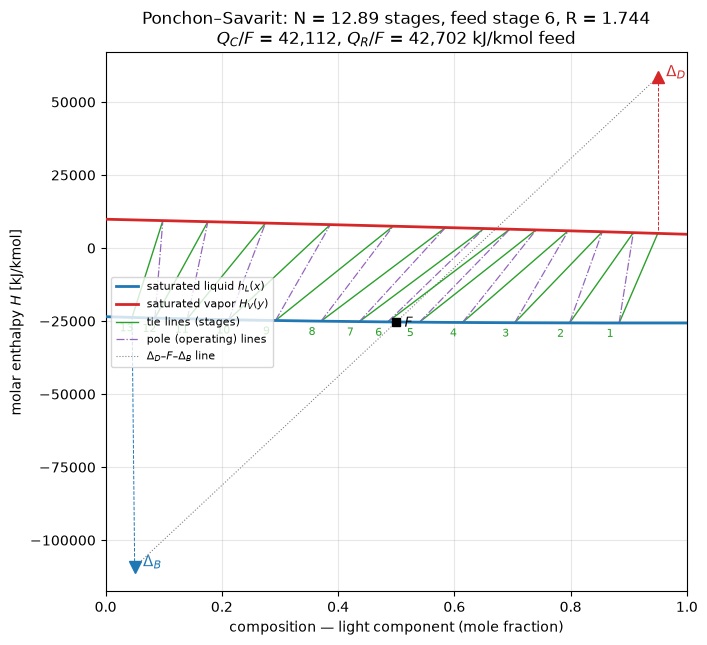

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 7))
plotting.plot_ponchon_savarit(ps_bt, ec_bt, ax=ax)
plt.show()

In [5]:
# Pinned expectations (a regression here means a real behavioral change).
assert abs(mt_bt.n_stages - 12.22) < 0.15, mt_bt.n_stages   # reproduces the M1-pinned value
assert abs(ps_bt.n_stages - 12.89) < 0.25, ps_bt.n_stages
assert ps_bt.feed_stage == mt_bt.feed_stage == 6
# Near-ideal: the two methods agree within ~1 stage.
assert abs(ps_bt.n_stages - mt_bt.n_stages) < 1.0
print("OK — Ponchon-Savarit and McCabe-Thiele agree for near-ideal benzene-toluene.")

OK — Ponchon-Savarit and McCabe-Thiele agree for near-ideal benzene-toluene.


## Worked example 2 — methanol–water: the CMO error appears

Methanol–water is nonideal (positive deviation, a real heat of mixing), so CMO is imperfect and
the two methods **diverge**. Same spec, van Laar γ-φ liquid (the vle Chapter IV parameters
$A_{12} = 0.5853$, $A_{21} = 0.3458$).

In [6]:
sys_mw = stages.ThermoSystem.van_laar(["methanol", "water"], 0.5853, 0.3458)
ec_mw = stages.EnthalpyCurve.from_thermo(sys_mw, P, n_points=401)
eq_mw = stages.EquilibriumCurve.from_points(list(ec_mw.x), list(ec_mw.y), list(ec_mw.t), P)

R2 = 1.5 * stages.rmin(eq_mw, 0.95, 0.05, 0.50).r_min
ps_mw = stages.ponchon_savarit(ec_mw, x_distillate=0.95, x_bottoms=0.05, z_feed=0.50, reflux=R2)
mt_mw = stages.mccabe_thiele(eq_mw, x_distillate=0.95, x_bottoms=0.05, z_feed=0.50, reflux=R2)

gap = ps_mw.n_stages - mt_mw.n_stages
print(f"Ponchon-Savarit : N = {ps_mw.n_stages:.3f}")
print(f"McCabe-Thiele   : N = {mt_mw.n_stages:.3f}")
print(f"CMO error (P-S - M-T) = {gap:+.3f} stages")
print(f"duties (P-S): Q_C/F = {ps_mw.q_condenser:,.0f}, Q_R/F = {ps_mw.q_reboiler:,.0f} kJ/kmol feed")

Ponchon-Savarit : N = 8.369
McCabe-Thiele   : N = 7.965
CMO error (P-S - M-T) = +0.404 stages
duties (P-S): Q_C/F = 34,789, Q_R/F = 35,055 kJ/kmol feed


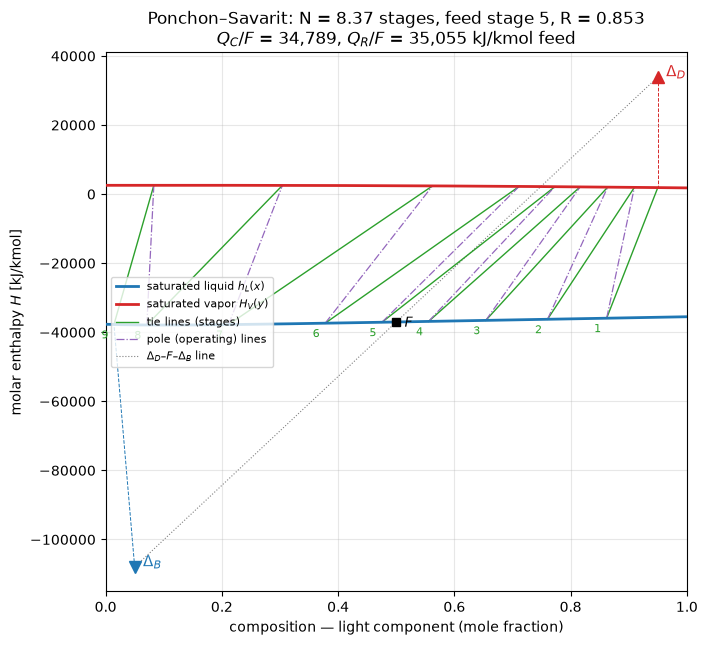

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 7))
plotting.plot_ponchon_savarit(ps_mw, ec_mw, ax=ax)
plt.show()

In [8]:
# The heat of mixing makes CMO under-count: P-S needs more stages than M-T here.
assert abs(mt_mw.n_stages - 7.97) < 0.2, mt_mw.n_stages
assert abs(ps_mw.n_stages - 8.37) < 0.2, ps_mw.n_stages
assert ps_mw.n_stages > mt_mw.n_stages, "expected a CMO-error gap"
print(f"OK — CMO under-counts by {gap:.2f} stages for methanol-water.")

OK — CMO under-counts by 0.40 stages for methanol-water.


## Worked example 3 — ammonia–water: computed chart vs reference chart

Ammonia–water is *the* Ponchon–Savarit showcase: its heat of mixing is enormous, so McCabe–Thiele
is badly wrong and you genuinely need the energy-exact method. But there is a subtlety — the
historical chart (Merkel–Bošnjaković; modern refinements Ibrahim–Klein 1993, Tillner-Roth 1998)
is a **data artifact** built from experimental VLE + calorimetry, not an on-the-fly model. So we
step the construction **two ways** (full discussion in
[`docs/theory/ponchon-savarit.md`](../docs/theory/ponchon-savarit.md)):

- **Route (a)** — *compute* the H–x–y chart from an NRTL γ-φ model and step off stages.
- **Route (b)** — *feed reference data* through `EnthalpyCurve.from_points` and run the same
  construction.

### Route (a): the NRTL-computed chart

NRTL parameters for NH₃(1)–H₂O(2), carried over from vle-thermo's Milestone 14 (α = 0.2, the
recommended ammonia value; interaction energies chosen to reproduce the hallmark **negative
deviation** and **exothermic mixing**; magnitudes illustrative, not a certified regression).

In [9]:
sys_aw = stages.ThermoSystem.nrtl(["ammonia", "water"], a12=-1800.0, a21=-1200.0, alpha=0.2)
ec_a = stages.EnthalpyCurve.from_thermo(sys_aw, P, n_points=121)

x = np.array(ec_a.x); y = np.array(ec_a.y); T = np.array(ec_a.t)
print(f"bubble-T range: {T.min():.1f} - {T.max():.1f} K  (ammonia is very volatile)")

# Easy split (huge relative volatility): x_D = 0.98, x_B = 0.02, z_F = 0.30, R = 1.5.
spec = dict(x_distillate=0.98, x_bottoms=0.02, z_feed=0.30, reflux=1.5)
ps_a = stages.ponchon_savarit(ec_a, **spec)
print(f"route (a) NRTL : N = {ps_a.n_stages:.3f}, feed {ps_a.feed_stage}, "
      f"Q_C/F = {ps_a.q_condenser:,.0f}, Q_R/F = {ps_a.q_reboiler:,.0f} kJ/kmol feed")

bubble-T range: 239.7 - 373.6 K  (ammonia is very volatile)
route (a) NRTL : N = 2.458, feed 1, Q_C/F = 19,254, Q_R/F = 24,663 kJ/kmol feed


### Route (b): the reference chart

Real ammonia–water calorimetry shows a heat of mixing **deeper and more asymmetric** than a
three-parameter NRTL fit can match (see the lesson). We emulate the reference chart by keeping
the NRTL vapor–liquid equilibrium but replacing the *liquid enthalpy* with a reference-style
excess enthalpy $H^E(x) = -x(1-x)\,[C_0 + C_1(1-2x)]$ — an illustrative stand-in for digitized
Bošnjaković / Ibrahim–Klein points, fed straight through `from_points`. (For production work,
digitize the published charts; here the point is the *mechanism* and the *sensitivity*.)

In [10]:
hL = np.array(ec_a.h_liq); hV = np.array(ec_a.h_vap)
C0, C1 = 24000.0, 8000.0                      # reference-style excess (kJ/kmol), endpoints fixed
hL_ref = hL - x * (1 - x) * (C0 + C1 * (1 - 2 * x))

# Peak heat of mixing, each chart (excess vs the ideal endpoint line).
ideal_a = x * hL[-1] + (1 - x) * hL[0]
ideal_b = x * hL_ref[-1] + (1 - x) * hL_ref[0]
print(f"H^E peak: NRTL (a) = {(hL - ideal_a).min():,.0f}   reference (b) = {(hL_ref - ideal_b).min():,.0f} kJ/kmol")

# Python from_points signature: (x, y, h_liq, h_vap, t, pressure)
ec_b = stages.EnthalpyCurve.from_points(list(x), list(y), list(hL_ref), list(hV), list(T), P)
ps_b = stages.ponchon_savarit(ec_b, **spec)

# McCabe-Thiele on the same VLE — CMO ignores the heat of mixing entirely.
eq_aw = stages.EquilibriumCurve.from_points(list(x), list(y), list(T), P)
mt_aw = stages.mccabe_thiele(eq_aw, **spec)

print(f"route (b) ref  : N = {ps_b.n_stages:.3f}, feed {ps_b.feed_stage}, "
      f"Q_C/F = {ps_b.q_condenser:,.0f}, Q_R/F = {ps_b.q_reboiler:,.0f} kJ/kmol feed")
print(f"McCabe-Thiele  : N = {mt_aw.n_stages:.3f}  (no duties — CMO cannot close the energy balance)")

H^E peak: NRTL (a) = -6,308   reference (b) = -12,456 kJ/kmol
route (b) ref  : N = 2.465, feed 1, Q_C/F = 19,488, Q_R/F = 30,076 kJ/kmol feed
McCabe-Thiele  : N = 2.308  (no duties — CMO cannot close the energy balance)


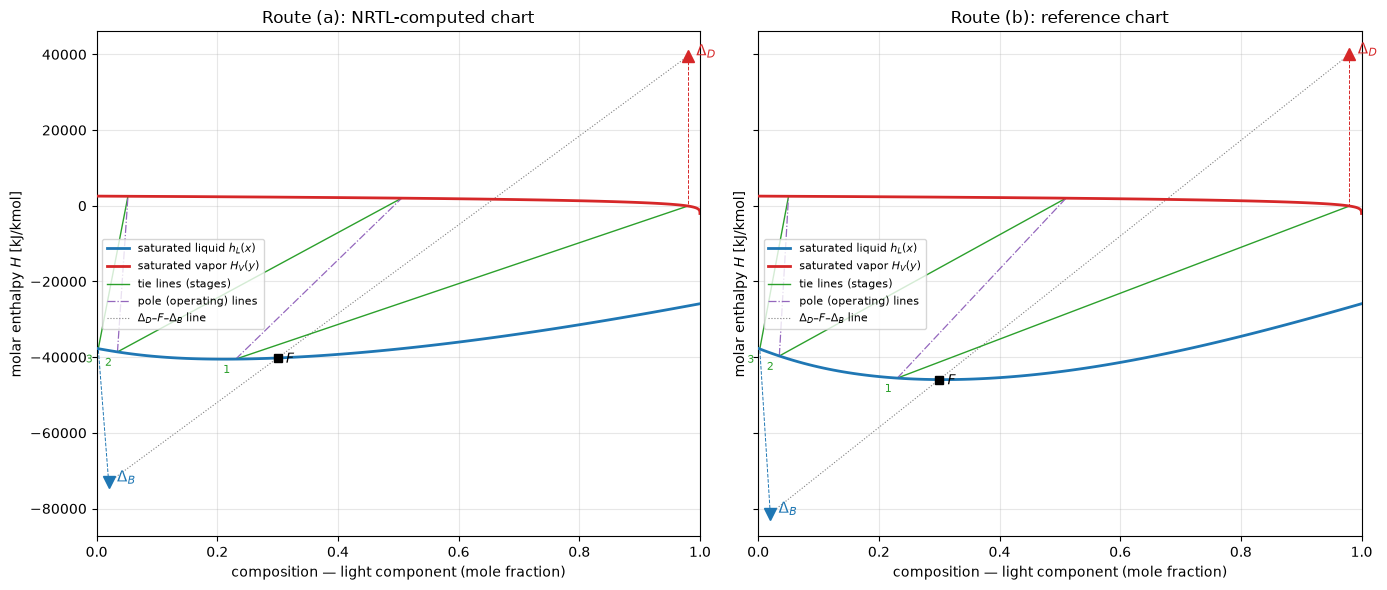

In [11]:
# The two H-x-y charts, side by side: the reference liquid curve bows deeper.
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
plotting.plot_ponchon_savarit(ps_a, ec_a, ax=axes[0])
axes[0].set_title("Route (a): NRTL-computed chart")
plotting.plot_ponchon_savarit(ps_b, ec_b, ax=axes[1])
axes[1].set_title("Route (b): reference chart")
plt.tight_layout()
plt.show()

### The gap is the lesson

For ammonia–water the **stage count barely moves** between the two charts — ammonia is so volatile
that $N$ is insensitive — but the **reboiler duty shifts by ~20%**, driven entirely by the
heat-of-mixing curvature that separates the two enthalpy charts. And McCabe–Thiele, which assumes
that curvature away, cannot produce a duty at all. That is the whole reason Ponchon–Savarit exists,
and why the honest way to reproduce the textbook ammonia–water chart is from reference data
(route b), not from a general-purpose activity model (route a).

In [12]:
gap_QR = ps_b.q_reboiler - ps_a.q_reboiler
print(f"stage count:   route (a) {ps_a.n_stages:.2f}  vs  route (b) {ps_b.n_stages:.2f}  "
      f"(nearly identical — ammonia is too volatile for N to care)")
print(f"reboiler duty: route (a) {ps_a.q_reboiler:,.0f}  vs  route (b) {ps_b.q_reboiler:,.0f}  "
      f"kJ/kmol feed  ->  {100*gap_QR/ps_a.q_reboiler:+.0f}% from the enthalpy chart alone")

# Pinned expectations.
assert abs(ps_a.n_stages - 2.46) < 0.1 and abs(ps_b.n_stages - 2.46) < 0.1
assert ps_a.q_condenser > 0 and ps_a.q_reboiler > 0        # physically signed
assert ps_b.q_reboiler > ps_a.q_reboiler                   # deeper mixing -> more reboiler duty
assert mt_aw.n_stages < ps_a.n_stages                      # CMO under-counts here too
print("OK — same method, different enthalpy chart, ~20% duty swing; M-T can't compute duties.")

stage count:   route (a) 2.46  vs  route (b) 2.46  (nearly identical — ammonia is too volatile for N to care)
reboiler duty: route (a) 24,663  vs  route (b) 30,076  kJ/kmol feed  ->  +22% from the enthalpy chart alone
OK — same method, different enthalpy chart, ~20% duty swing; M-T can't compute duties.


## Exercises

Two exercises. Templates first; worked solutions are collapsed at the bottom.

### Exercise 1 — reflux vs energy

More reflux buys fewer stages but costs more heat. For **benzene–toluene** (`ec_bt`, spec
$x_D=0.95$, $x_B=0.05$, $z_F=0.50$), compute the Ponchon–Savarit stage count $N$ and the reboiler
duty $Q_R/F$ at $R = 1.2,\ 1.5,\ 2.0,\ 3.0 \times R_{min}$, and confirm $N$ falls while $Q_R/F$ rises.

### Exercise 2 — how big is the CMO error?

For **methanol–water** (`ec_mw`), compute the Ponchon–Savarit vs McCabe–Thiele stage gap at feed
compositions $z_F \in \{0.30,\ 0.50,\ 0.70\}$ (same $x_D, x_B, R$). Report where CMO is worst.

In [13]:
# Exercise 1 — TODO: fill in.
# r_min_bt = stages.rmin(eq_bt, 0.95, 0.05, 0.50).r_min
# for factor in (1.2, 1.5, 2.0, 3.0):
#     R = factor * r_min_bt
#     res = stages.ponchon_savarit(ec_bt, x_distillate=0.95, x_bottoms=0.05, z_feed=0.50, reflux=R)
#     print(f"R = {factor:.1f} R_min:  N = {res.n_stages:.2f},  Q_R/F = {res.q_reboiler:,.0f} kJ/kmol")


In [14]:
# Exercise 2 — TODO: fill in.
# for zf in (0.30, 0.50, 0.70):
#     ps = stages.ponchon_savarit(ec_mw, x_distillate=0.95, x_bottoms=0.05, z_feed=zf, reflux=R2)
#     mt = stages.mccabe_thiele(eq_mw, x_distillate=0.95, x_bottoms=0.05, z_feed=zf, reflux=R2)
#     print(f"z_F = {zf:.2f}:  P-S {ps.n_stages:.2f}  M-T {mt.n_stages:.2f}  gap {ps.n_stages-mt.n_stages:+.2f}")


<details>
<summary><b>Solutions</b> (click to expand)</summary>

```python
# Exercise 1 — reflux vs energy (benzene-toluene)
r_min_bt = stages.rmin(eq_bt, 0.95, 0.05, 0.50).r_min
prev_N, prev_Q = None, None
for factor in (1.2, 1.5, 2.0, 3.0):
    R = factor * r_min_bt
    res = stages.ponchon_savarit(ec_bt, x_distillate=0.95, x_bottoms=0.05, z_feed=0.50, reflux=R)
    print(f"R = {factor:.1f} R_min:  N = {res.n_stages:5.2f},  Q_R/F = {res.q_reboiler:,.0f} kJ/kmol")
    if prev_N is not None:
        assert res.n_stages < prev_N        # more reflux -> fewer stages
        assert res.q_reboiler > prev_Q      # more reflux -> more boil-up -> more duty
    prev_N, prev_Q = res.n_stages, res.q_reboiler

# Exercise 2 — the CMO error vs feed composition (methanol-water)
for zf in (0.30, 0.50, 0.70):
    ps = stages.ponchon_savarit(ec_mw, x_distillate=0.95, x_bottoms=0.05, z_feed=zf, reflux=R2)
    mt = stages.mccabe_thiele(eq_mw, x_distillate=0.95, x_bottoms=0.05, z_feed=zf, reflux=R2)
    print(f"z_F = {zf:.2f}:  P-S {ps.n_stages:5.2f}  M-T {mt.n_stages:5.2f}  gap {ps.n_stages-mt.n_stages:+.2f}")
# The gap is a genuine (small but nonzero) CMO error at every feed composition.
```

</details>

## References

- **Method:** Ponchon (*La Technique Moderne* **1921**), Savarit (*Arts et Métiers* **1922**);
  Seader, Henley & Roper, *Separation Process Principles*, Ch. 7. Theory as implemented:
  [`docs/theory/ponchon-savarit.md`](../docs/theory/ponchon-savarit.md).
- **NRTL liquid model:** Renon & Prausnitz, *AIChE J.* **1968**, 14, 135 (in vle-thermo).
- **Ammonia–water charts:** Merkel & Bošnjaković (1929); Bošnjaković (1935); Ibrahim & Klein,
  *ASHRAE Trans.* **1993**, 99(1), 1495; Tillner-Roth & Friend, *J. Phys. Chem. Ref. Data*
  **1998**, 27, 63. Full list + the "UNIQUAC trap" discussion:
  [`docs/references.md`](../docs/references.md).
- **Algorithm design:** `PLAN.md` §4–§5 (the pedagogical ladder); code in
  [`engine/src/binary/ponchon_savarit.rs`](../engine/src/binary/ponchon_savarit.rs).